# Ejercicio Regression Tree
Son datos de temperaturas tomados de la ciudad de Seattle. El objetivo es intentar predecir lo mejor posible la máxima temperatura (columna `actual`) que alcanzaremos al día siguiente. Para ello contaremos con temperaturas de los dos días anteriores, históricos de máximas temperaturas y un amigo bastante chapas que te da su predicción del tiempo cada día.

**Resumen de datos**:
* year: 2016 for all data points
* month: number for month of the year
* day: number for day of the year
* week: day of the week as a character string
* temp_2: max temperature 2 days prior
* temp_1: max temperature 1 day prior
* average: historical average max temperature
* actual: max temperature measurement
* friend: your friend’s prediction, a random number between 20 below the average and 20 above the average


### 1. Importa el csv "temps.csv"

In [87]:
import numpy as np
import pandas as pd
import os
import sklearn
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
df = pd.read_csv('data/temps.csv')
df

,year,month,day,week,temp_2,temp_1,average,actual,friend
0,2016,1,1,Fri,45,45,45.6,45,29
1,2016,1,2,Sat,44,45,45.7,44,61
2,2016,1,3,Sun,45,44,45.8,41,56
3,2016,1,4,Mon,44,41,45.9,40,53
4,2016,1,5,Tues,41,40,46.0,44,41
...,...,...,...,...,...,...,...,...,...
343,2016,12,27,Tues,42,42,45.2,47,47
344,2016,12,28,Wed,42,47,45.3,48,58
345,2016,12,29,Thurs,47,48,45.3,48,65
346,2016,12,30,Fri,48,48,45.4,57,42


### 2. Realiza un análisis exploratorio junto con un Feature Engineering

In [95]:
df[['temp_2', 'temp_1', 'average', 'actual']] = ((df[['temp_2', 'temp_1', 'average', 'actual']] - 32) * 5 / 9 ).round(2)

In [99]:
df.drop(columns=['year', 'day', 'week', 'friend'], inplace=True)

In [100]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   month    348 non-null    int64  
 1   temp_2   348 non-null    float64
 2   temp_1   348 non-null    float64
 3   average  348 non-null    float64
 4   actual   348 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 13.7 KB


In [101]:
df.describe()

,month,temp_2,temp_1,average,actual
count,348.000000,348.000000,348.000000,348.000000,348.000000
mean,6.477011,17.029080,17.056207,15.422500,16.968420
std,3.498380,6.758302,6.733401,5.848529,6.552096
min,1.000000,1.670000,1.670000,7.280000,1.670000
25%,3.000000,12.220000,12.220000,9.985000,12.220000
50%,6.000000,16.945000,16.945000,14.555000,16.945000
75%,10.000000,21.670000,21.670000,20.572500,21.670000
max,12.000000,47.220000,47.220000,25.220000,33.330000


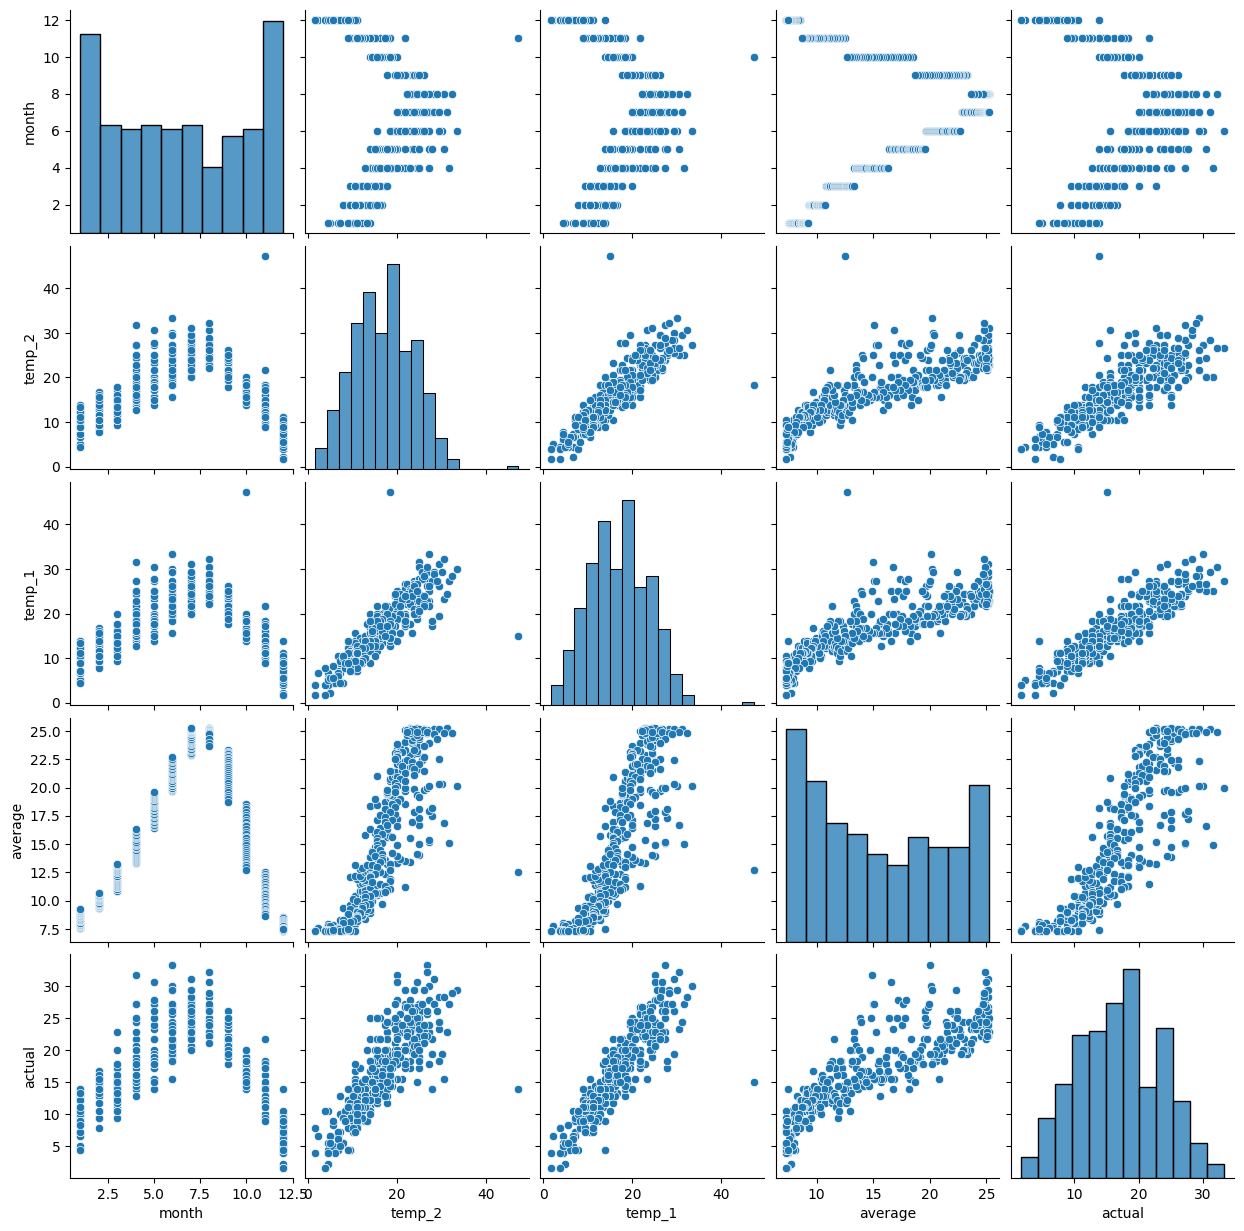

In [102]:
sns.pairplot(df);

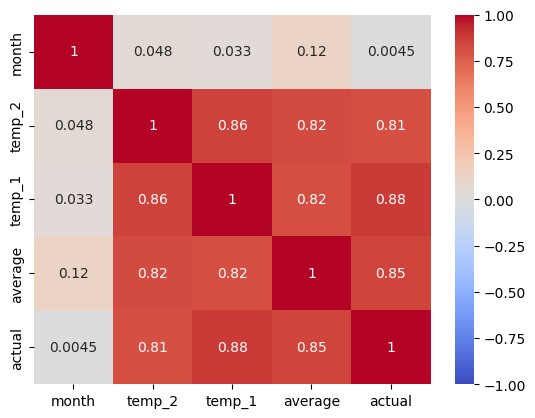

In [103]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", vmin=-1);

### 3. Selecciona variables y divide en train y test

In [105]:
X = df[['temp_2', 'temp_1', 'average']]
y = df[['actual']]

In [106]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [107]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scal = scaler.fit_transform(X_train)
X_test_scal = scaler.transform(X_test)
scaler.inverse_transform(X_test_scal)

array([[20.56, 20.  , 18.94],
       [15.  , 15.56, 15.94],
       [11.67,  8.89,  8.89],
       [15.56, 16.67, 16.11],
       [19.44, 18.33, 21.33],
       [20.  , 25.  , 17.22],
       [23.89, 26.67, 25.06],
       [32.22, 28.33, 24.78],
       [14.44, 15.56, 13.11],
       [26.67, 27.22, 20.  ],
       [14.44, 17.22, 12.33],
       [33.33, 30.  , 20.17],
       [ 5.  ,  2.22,  7.72],
       [22.78, 17.78, 15.5 ],
       [23.89, 20.  , 21.94],
       [10.56, 13.89,  9.67],
       [21.67, 18.33, 11.22],
       [16.11, 12.78, 12.5 ],
       [15.56, 13.89, 10.72],
       [25.56, 29.44, 22.44],
       [17.22, 18.89, 17.39],
       [12.78, 13.33, 10.  ],
       [18.89, 15.56, 20.94],
       [15.56, 15.56, 15.5 ],
       [12.22, 13.89, 12.89],
       [10.56, 12.22,  9.06],
       [15.  , 18.89, 18.94],
       [ 8.89, 10.  ,  8.06],
       [18.89, 15.  , 18.83],
       [23.89, 25.  , 24.44],
       [27.22, 22.78, 15.39],
       [16.11, 17.78, 16.22],
       [11.11, 13.89,  8.89],
       [28

In [ ]:
### CROS VALIDATION SIN HACER

### 4. Entrena el modelo


In [154]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(random_state=42, max_depth=4)
model.fit(X_train_scal, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

### 5. Evaluación de tu modelo
Calcula el coeficiente de determinación. 

Calcula el MAE, MAPE, MSE y RMSE.

In [140]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

In [ ]:
y_pred_train = model.predict(X_train_scal)
y_pred_test  = model.predict(X_test_scal)

print("Train MAE:", mean_absolute_error(y_train, y_pred_train))
print("Test MAE:", mean_absolute_error(y_test, y_pred_test))

print("Train MAPE:", mean_absolute_percentage_error(y_train, y_pred_train))
print("Test MAPE:", mean_absolute_percentage_error(y_test, y_pred_test))

print("Train MSE:", mean_squared_error(y_train, y_pred_train))
print("Test MSE:", mean_squared_error(y_test, y_pred_test))

print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))


Train MAE: 1.833718668939884
Test MAE: 2.2420190007903544
Train MAPE: 0.12746204712382908
Test MAPE: 0.15693723324078782
Train MSE: 5.675137335622195
Test MSE: 8.827466999123024
Train RMSE: 2.382254674803304
Test RMSE: 2.9711053497180178


In [157]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

def evaluate_model(name, y_train, y_pred_train, y_test, y_pred_test):

    mae_train  = mean_absolute_error(y_train, y_pred_train)
    mape_train = mean_absolute_percentage_error(y_train, y_pred_train)
    mse_train  = mean_squared_error(y_train, y_pred_train)
    rmse_train = np.sqrt(mse_train)
    r2_train   = r2_score(y_train, y_pred_train)

    mae_test  = mean_absolute_error(y_test, y_pred_test)
    mape_test = mean_absolute_percentage_error(y_test, y_pred_test)
    mse_test  = mean_squared_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)
    r2_test   = r2_score(y_test, y_pred_test)

    print(f"--- {name} ---")
    print(f"MAE_train:  {mae_train:.4f}     MAE_test:  {mae_test:.4f}")
    print(f"MAPE_train: {mape_train:.4f}    MAPE_test: {mape_test:.4f}")
    print(f"MSE_train:  {mse_train:.4f}     MSE_test:  {mse_test:.4f}")
    print(f"RMSE_train: {rmse_train:.4f}    RMSE_test: {rmse_test:.4f}")
    print(f"R2_train:   {r2_train:.4f}       R2_test:   {r2_test:.4f}\n")


In [158]:
evaluate_model(
    "DecisionTree",
    y_train, model.predict(X_train_scal),
    y_test, model.predict(X_test_scal)
)

--- DecisionTree ---
MAE_train:  1.8337     MAE_test:  2.2420
MAPE_train: 0.1275    MAPE_test: 0.1569
MSE_train:  5.6751     MSE_test:  8.8275
RMSE_train: 2.3823    RMSE_test: 2.9711
R2_train:   0.8670       R2_test:   0.7954



### 6. Representa el árbol de decisión

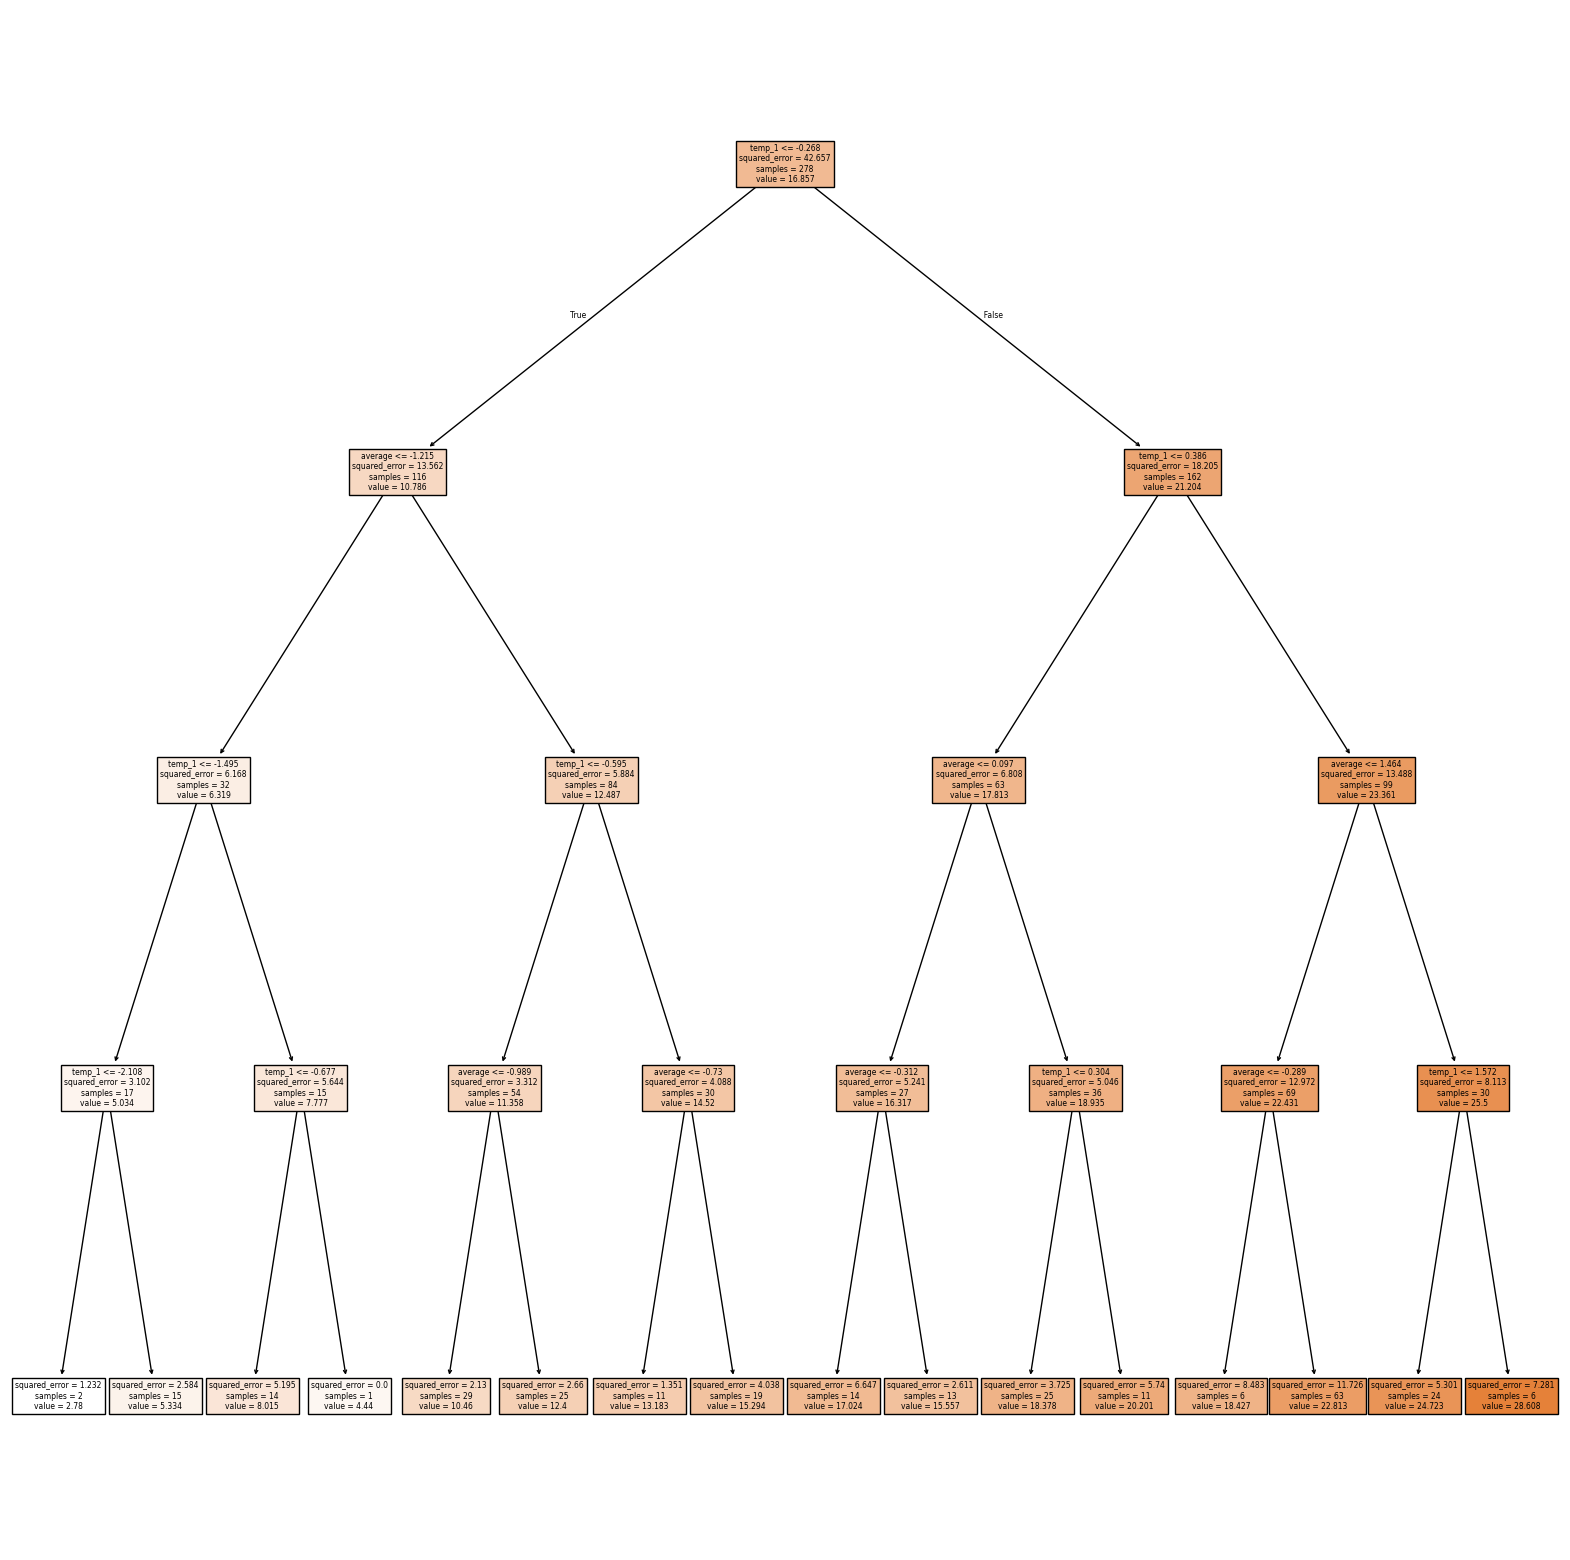

In [134]:
plt.figure(figsize=(20,20))
sklearn.tree.plot_tree(model,
                       feature_names=['temp_2', 'temp_1', 'average'],
                       class_names=None,
                       filled = True);

### 7. Modifica el max_depth a 3 y vuelve a entrenarlo

In [155]:
model_3 = DecisionTreeRegressor(random_state=42, max_depth=3)
model_3.fit(X_train_scal, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

### 8. Vuelve a evaluar tu modelo

In [160]:
evaluate_model(
    "DecisionTree",
    y_train, model_3.predict(X_train_scal),
    y_test, model_3.predict(X_test_scal)
)

--- DecisionTree ---
MAE_train:  2.0421     MAE_test:  2.3704
MAPE_train: 0.1453    MAPE_test: 0.1618
MSE_train:  6.8363     MSE_test:  9.5479
RMSE_train: 2.6146    RMSE_test: 3.0900
R2_train:   0.8397       R2_test:   0.7787



### 9. Vuelve a representar su árbol

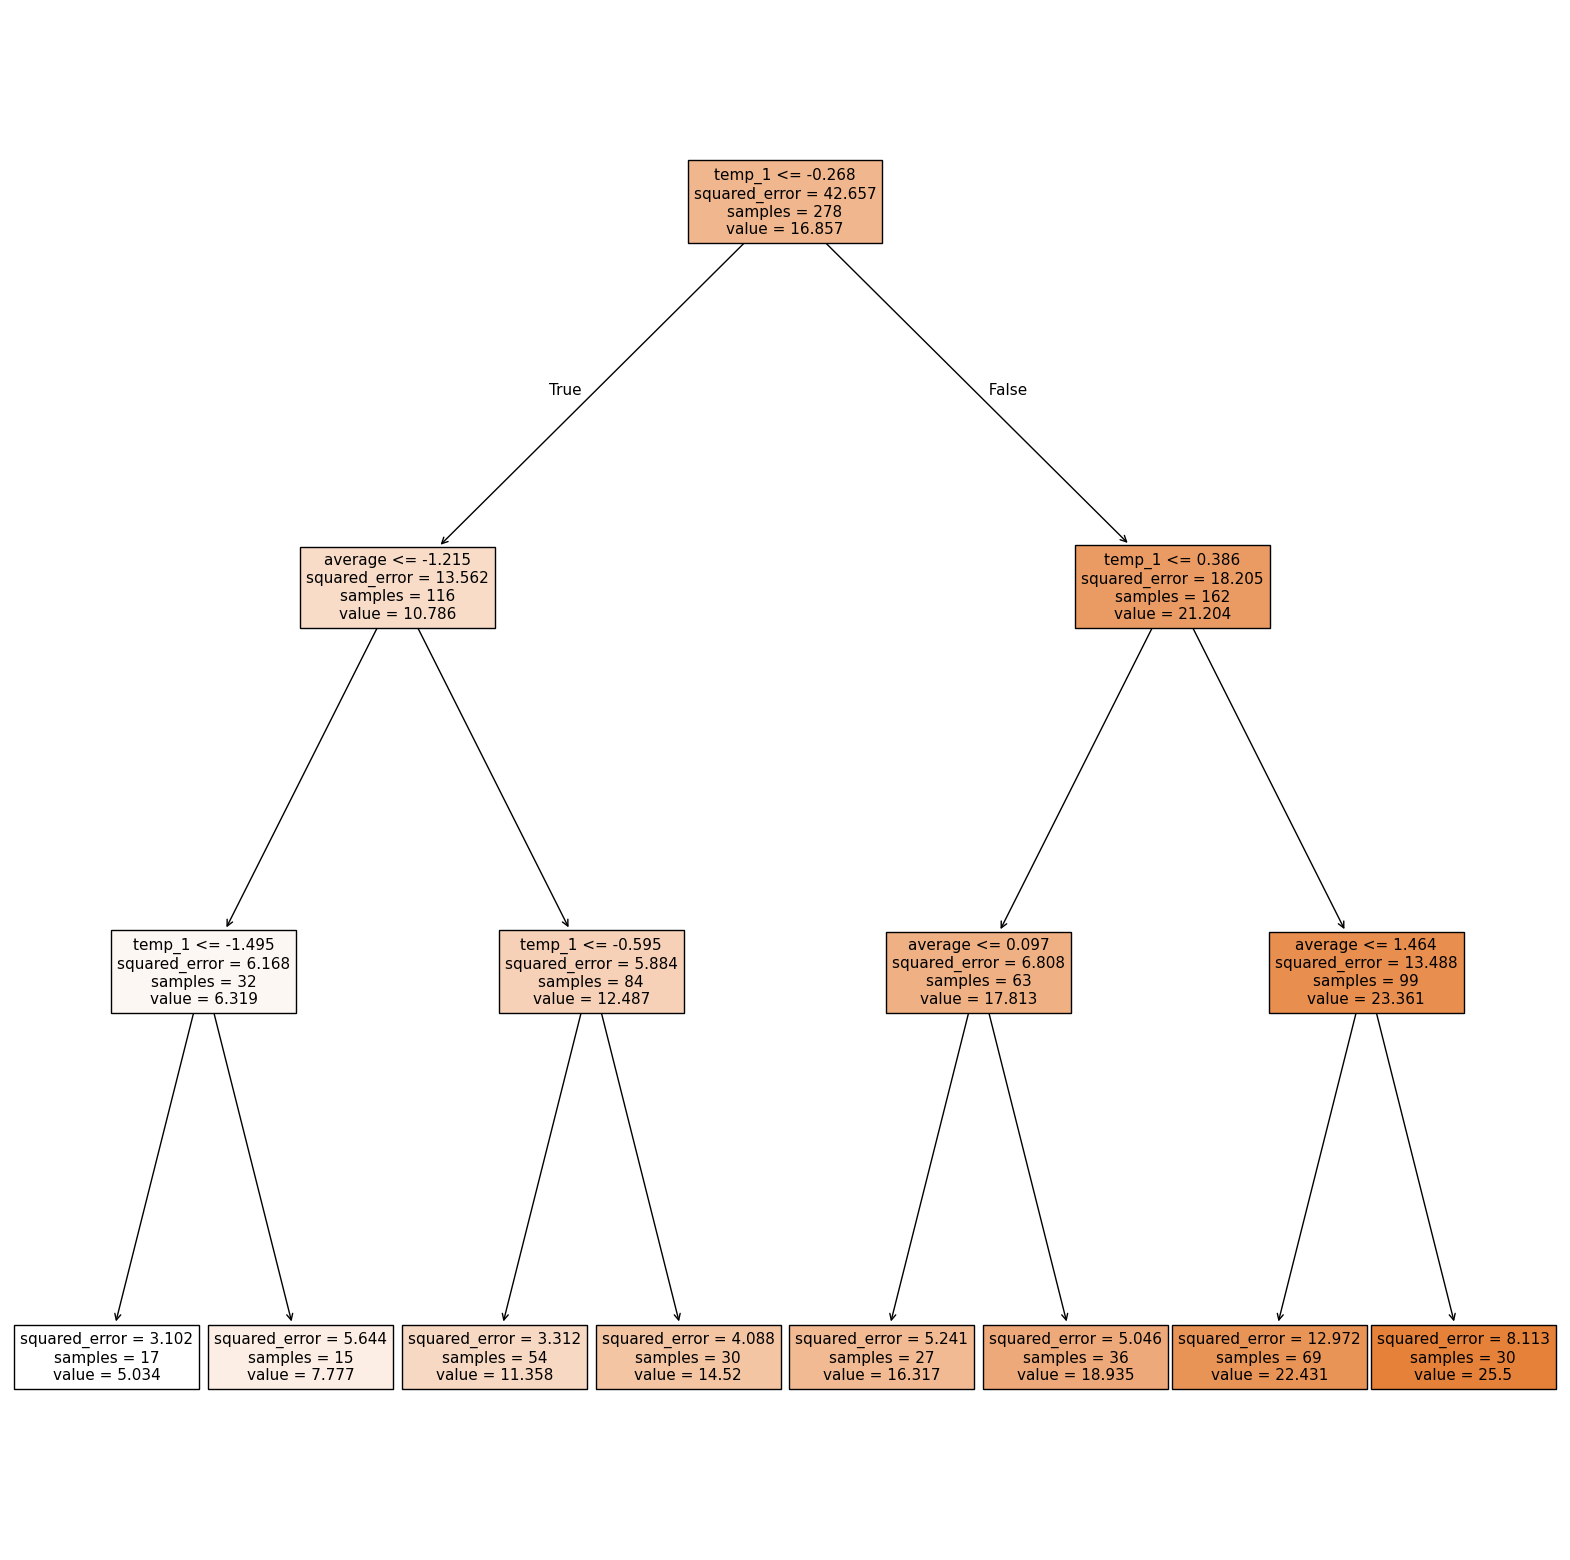

In [161]:
plt.figure(figsize=(20,20))
sklearn.tree.plot_tree(model_3,
                       feature_names=['temp_2', 'temp_1', 'average'],
                       class_names=None,
                       filled = True);

### 10. Utiliza un grid search con cross validation para hiperparametrizar tu modelo

### 11. Obten el `feature_importances` de cada variable en el último modelo

### 12. Construye un nuevo modelo `DecisionTreeClassifier` que te clasifique cuando en un día va a hacer una temperatura mayor a 15ºC (59ºF). ¡Deberá tratarse como un problema de **clasificación**! Utiliza un grid search con cross validation y evalúa el mejor modelo.